# Maybank (1155.KL) 5-Day Swing Trading Signal Prediction with XGBoost
### Using FBM KLCI (Top 30 Malaysian companies index) as a market-context feature

This notebook builds a **3-class swing classifier** that predicts a 5-day trading action for **Maybank (1155.KL)**:

| Class | Meaning | Trigger (5-Day Horizon) |
|---|---|---|
| `0` | **STILL** (Hold) | 5-day return stays inside neutral band `[-1.0%, +1.0%]` |
| `1` | **UP** (Buy)  | 5-day return is $> +1.0\%$ |
| `2` | **DOWN** (Sell) | 5-day return is $< -1.0\%$ |

using:
- Maybank's own OHLCV-derived pruned technical features (momentum, trend, volatility, volume)
- FBM KLCI (`^KLSE`) market-context and relative-strength alpha features

**Structure of this notebook:**
1. Data Cleaning
2. Time-Series Data Split (Train : Valid : Test = 6 : 2 : 2 with Embargo Purge)
3. Pruned Feature Engineering (12 Orthogonal Signals)
4. XGBoost Hyperparameter & Threshold Tuning (Optuna)
5. Baseline Comparison
6. Full Model Evaluation Results
7. Test (Production) Score
8. Mock Trading Simulation (5-Day Swing Holding Period)

## 0. Setup & Installs

Install/import all required libraries. `ta` is used for technical-analysis indicators, `xgboost` for the classifier.

In [76]:
import warnings
from itertools import product

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import ta
import optuna
import yfinance as yf


from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 50)
sns.set_style("whitegrid")
RANDOM_STATE = 42

In [77]:
# --- Config ---
MAYBANK_TICKER = "1155.KL"  # Maybank on Bursa Malaysia
KLCI_TICKER = "^KLSE"  # FTSE Bursa Malaysia KLCI (top 30 companies, incl. Maybank)

START_DATE = "2010-01-01"
END_DATE = None  # None = up to today

print(f"Maybank ticker : {MAYBANK_TICKER}")
print(f"FBM KLCI ticker: {KLCI_TICKER}")

Maybank ticker : 1155.KL
FBM KLCI ticker: ^KLSE


## Download Raw Data

We pull daily OHLCV data for both Maybank and the FBM KLCI index with `auto_adjust=True` so that all prices (Open, High, Low, Close) are split- and dividend-adjusted.

> **Why Adjusted Prices Matter:** Maybank is one of Bursa Malaysia's largest blue-chip dividend payers (typically yielding 5%–7% annually). If unadjusted prices were used, each ex-dividend date would show an artificial overnight price drop of 20–30+ sen, falsely signaling massive market sell-offs (`DOWN` signal) and distorting momentum/moving-average indicators.

The KLCI series is merged in as *contextual/market* features — Maybank is one of the index's largest constituents, so the index's own momentum/trend carries predictive market-context signal.

In [78]:
maybank_raw = yf.download(
    MAYBANK_TICKER, start=START_DATE, end=END_DATE, auto_adjust=True, progress=False
)
klci_raw = yf.download(
    KLCI_TICKER, start=START_DATE, end=END_DATE, auto_adjust=True, progress=False
)

# yfinance sometimes returns MultiIndex columns for a single ticker - flatten if needed
if isinstance(maybank_raw.columns, pd.MultiIndex):
    maybank_raw.columns = maybank_raw.columns.get_level_values(0)
if isinstance(klci_raw.columns, pd.MultiIndex):
    klci_raw.columns = klci_raw.columns.get_level_values(0)

print("Maybank shape:", maybank_raw.shape)
print("KLCI shape   :", klci_raw.shape)
maybank_raw.tail()

Maybank shape: (4119, 5)
KLCI shape   : (4095, 5)


Price,Close,High,Low,Open,Volume
Date,,,,,
2026-09-15,10.42,10.48,10.40,10.48,11314800
2026-09-17,10.36,10.48,10.34,10.44,11221000
2026-09-18,10.32,10.42,10.32,10.36,15504800
2026-09-21,10.38,10.44,10.32,10.34,12127000
2026-09-22,10.44,10.46,10.36,10.40,20591800


## 1. Data Cleaning

Requirement: **drop rows that have null values in OHLCV (Open, High, Low, Close, Volume)**, for both Maybank and the FBM KLCI series, before any feature engineering happens. We also align both series on the trading calendar (inner join on date), since holidays can differ slightly and we need matched dates when merging KLCI features onto Maybank rows.

In [79]:
def clean_ohlcv(df, name):
    ohlcv_cols = ["Open", "High", "Low", "Close", "Volume"]
    before = len(df)
    df = df.copy()

    # Keep only rows where all OHLCV columns are present and non-null
    df = df.dropna(subset=ohlcv_cols)

    # Defensive: drop any rows where volume is 0 (non-trading / bad data) which can break pct_change features
    df = df[df["Volume"] > 0]

    after = len(df)
    print(
        f"[{name}] Dropped {before - after} rows with null/invalid OHLCV out of {before} total rows."
    )
    return df


maybank_clean = clean_ohlcv(maybank_raw, "Maybank")
klci_clean = clean_ohlcv(klci_raw, "FBM KLCI")

# Align both series on shared trading dates (inner join) so KLCI features line up 1-to-1 with Maybank rows
common_dates = maybank_clean.index.intersection(klci_clean.index)
maybank_clean = maybank_clean.loc[common_dates].sort_index()
klci_clean = klci_clean.loc[common_dates].sort_index()

print(f"\nAligned shape (both series): {maybank_clean.shape}")
assert maybank_clean.isna().sum().sum() == 0, "Nulls remain in Maybank OHLCV!"
assert klci_clean.isna().sum().sum() == 0, "Nulls remain in KLCI OHLCV!"
print("No nulls remain in either OHLCV dataset. ✅")

[Maybank] Dropped 32 rows with null/invalid OHLCV out of 4119 total rows.
[FBM KLCI] Dropped 17 rows with null/invalid OHLCV out of 4095 total rows.

Aligned shape (both series): (4071, 5)
No nulls remain in either OHLCV dataset. ✅


## 2. Time-Series Data Split (Train : Valid : Test = 6 : 2 : 2)

Because this is time-series data, we **never shuffle**. We split chronologically:

- **Train (60%)** — used to fit the model
- **Valid (20%)** — used for hyperparameter tuning / early stopping
- **Test (20%)** — held out completely, touched only once at the end, to simulate genuine "production" performance on unseen future data

We compute the split **cutoff dates** here on the cleaned, aligned date index. The actual feature matrix (built in Section 3) will be sliced using these same cutoff dates, so there is no leakage of future information into earlier splits (e.g. no rolling-window feature is allowed to peek across the boundary in a way that uses test labels).

In [80]:
n = len(maybank_clean)
train_end_idx = int(n * 0.6)
valid_end_idx = int(n * 0.8)  # 0.7 + 0.2

train_dates = maybank_clean.index[:train_end_idx]
valid_dates = maybank_clean.index[train_end_idx:valid_end_idx]
test_dates = maybank_clean.index[valid_end_idx:]

print(f"Total rows : {n}")
print(
    f"Train      : {len(train_dates):>5} rows  ({train_dates.min().date()} -> {train_dates.max().date()})"
)
print(
    f"Valid      : {len(valid_dates):>5} rows  ({valid_dates.min().date()} -> {valid_dates.max().date()})"
)
print(
    f"Test (prod): {len(test_dates):>5} rows  ({test_dates.min().date()} -> {test_dates.max().date()})"
)
print(
    f"\nRatio check -> train: {len(train_dates) / n:.2%}, valid: {len(valid_dates) / n:.2%}, test: {len(test_dates) / n:.2%}"
)

Total rows : 4071
Train      :  2442 rows  (2010-01-04 -> 2020-01-08)
Valid      :   814 rows  (2020-01-09 -> 2023-05-22)
Test (prod):   815 rows  (2023-05-23 -> 2026-09-21)

Ratio check -> train: 59.99%, valid: 20.00%, test: 20.02%


## 3. Feature Engineering (Pruned & Orthogonal Feature Architecture)

Following correlation diagnostics (which revealed over 40 pairs of features with correlation $|r| > 0.80$), we pruned the feature space down from 39 collinear variables to **12 highly informative, orthogonal signals**:

1. **Maybank Momentum & Acceleration:**
   - `rsi_14`: 14-day Relative Strength Index (overbought/oversold levels).
   - `macd_diff`: MACD histogram (diff between MACD and signal line, measuring momentum acceleration).
2. **Maybank Trend & Level Regimes:**
   - `price_to_sma20`: Distance from 20-day SMA (short/medium mean-reversion).
   - `sma20_to_sma50`: Ratio of 20-day to 50-day SMA (medium/long-term trend slope).
3. **Maybank Volatility & Trend Strength:**
   - `adx_14`: Average Directional Index (trend strength regardless of direction).
   - `ret_std_10`: 10-day rolling standard deviation of returns (volatility regime).
4. **Maybank Volume:**
   - `volume_sma_ratio`: Volume surge relative to its 20-day moving average.
5. **FBM KLCI Market Context:**
   - `klci_price_to_sma20`: Broad market trend position.
   - `klci_macd_diff`: Broad market momentum acceleration.
   - `klci_ret_std_10`: Broad market volatility regime.
6. **Relative Alpha (Maybank vs. Market):**
   - `maybank_vs_klci_ret_5d`: 5-day rolling return spread (alpha outperformance over the benchmark).
   - `maybank_vs_klci_rsi_diff`: Relative momentum spread between Maybank and the index.

In [81]:
def build_pruned_features(df, prefix=""):
    """Extracts a clean, non-redundant set of technical signals from OHLCV data.
    Avoids multi-collinear duplicate moving averages and raw redundant indicators.
    """
    close = df["Close"]
    high = df["High"]
    low = df["Low"]
    volume = df["Volume"]

    feat = pd.DataFrame(index=df.index)

    # 1. Momentum & Acceleration
    feat["rsi_14"] = ta.momentum.RSIIndicator(close, window=14).rsi()
    macd = ta.trend.MACD(close)
    feat["macd_diff"] = macd.macd_diff()  # Histogram: captures momentum acceleration

    # 2. Trend & Moving Average Ratios (Stationary)
    sma_20 = ta.trend.SMAIndicator(close, window=20).sma_indicator()
    sma_50 = ta.trend.SMAIndicator(close, window=50).sma_indicator()
    feat["price_to_sma20"] = close / sma_20 - 1
    feat["sma20_to_sma50"] = sma_20 / sma_50 - 1

    # 3. Volatility & Trend Strength
    feat["adx_14"] = ta.trend.ADXIndicator(high, low, close, window=14).adx()
    feat["ret_std_10"] = close.pct_change().rolling(10).std()

    # 4. Volume Surge
    feat["volume_sma_ratio"] = volume / volume.rolling(20).mean() - 1

    if prefix:
        feat = feat.add_prefix(prefix)

    return feat


maybank_feat = build_pruned_features(maybank_clean)
klci_feat = build_pruned_features(klci_clean, prefix="klci_")

print("Maybank base features:", list(maybank_feat.columns))
print("KLCI base features   :", list(klci_feat.columns))

Maybank base features: ['rsi_14', 'macd_diff', 'price_to_sma20', 'sma20_to_sma50', 'adx_14', 'ret_std_10', 'volume_sma_ratio']
KLCI base features   : ['klci_rsi_14', 'klci_macd_diff', 'klci_price_to_sma20', 'klci_sma20_to_sma50', 'klci_adx_14', 'klci_ret_std_10', 'klci_volume_sma_ratio']


In [82]:
# Select the key KLCI market-context indicators (avoiding duplicate full set)
klci_selected = klci_feat[["klci_price_to_sma20", "klci_macd_diff", "klci_ret_std_10"]]

# Merge Maybank features with market-context features
features = maybank_feat.join(klci_selected, how="inner")

# Relative-strength alpha features: Maybank vs. FBM KLCI
maybank_ret = maybank_clean["Close"].pct_change()
klci_ret = klci_clean["Close"].pct_change()

features["maybank_vs_klci_ret_5d"] = (
    maybank_ret.rolling(5).mean() - klci_ret.rolling(5).mean()
)
features["maybank_vs_klci_rsi_diff"] = maybank_feat["rsi_14"] - klci_feat["klci_rsi_14"]

# Defensive: replace any infs from zero volume / price divisions with NaN
features = features.replace([np.inf, -np.inf], np.nan)

print(f"Final pruned feature matrix shape: {features.shape}")
print("Feature list (12 features):", list(features.columns))
features.tail()

Final pruned feature matrix shape: (4071, 12)
Feature list (12 features): ['rsi_14', 'macd_diff', 'price_to_sma20', 'sma20_to_sma50', 'adx_14', 'ret_std_10', 'volume_sma_ratio', 'klci_price_to_sma20', 'klci_macd_diff', 'klci_ret_std_10', 'maybank_vs_klci_ret_5d', 'maybank_vs_klci_rsi_diff']


,rsi_14,macd_diff,price_to_sma20,sma20_to_sma50,adx_14,ret_std_10,volume_sma_ratio,klci_price_to_sma20,klci_macd_diff,klci_ret_std_10,maybank_vs_klci_ret_5d,maybank_vs_klci_rsi_diff
Date,,,,,,,,,,,,
2026-09-14,39.898578,-0.009485,-0.010313,-0.016435,11.924175,0.005759,-0.657947,-0.013070,-3.969588,0.007084,-0.000315,-1.141110
2026-09-15,37.757533,-0.009331,-0.013258,-0.016577,12.780511,0.004853,-0.395522,-0.022628,-4.779612,0.006402,0.001845,3.060819
2026-09-17,34.745585,-0.011928,-0.017916,-0.016539,14.155855,0.004672,-0.402858,-0.023777,-5.290665,0.006042,0.002737,1.369716
2026-09-18,32.863466,-0.014810,-0.020315,-0.016837,15.612136,0.004695,-0.171606,-0.027206,-5.876057,0.005768,0.002032,2.079438
2026-09-21,38.265472,-0.011304,-0.013402,-0.017023,16.597035,0.005383,-0.347697,-0.024566,-5.790061,0.005865,0.002357,6.622145


### Target variable — 3-class trading signal (Calibrated 5-Day Swing Horizon)

Instead of noisy 1-day predictions, we define a **3-class trading action** based on a **5-day forward return horizon** (1 calendar trading week):

- **`1` = UP (Buy)** → 5-day forward return $> +1.0\%$ (`UP_THRESHOLD`)
- **`2` = DOWN (Sell)** → 5-day forward return $< -1.0\%$ (`DOWN_THRESHOLD`)
- **`0` = STILL (Hold)** → 5-day forward return falls inside $[-1.0\%, +1.0\%]$ (market chop / insufficient move after fees)

Empirical calibration on Maybank's 5-day return distribution shows that $\pm 1.0\%$ provides a realistic balance (~53.7% STILL, ~26.8% UP, ~19.5% DOWN), providing clear breakout signals while maintaining enough training examples for tree splits.

In [83]:
# --- Multi-Day Forward Horizon & Calibrated Thresholds ---
HORIZON = 5  # 5 trading days forward (1 calendar week swing horizon)
UP_THRESHOLD = 0.010  # 5-day gain > +1.0% -> UP (Buy)
DOWN_THRESHOLD = -0.010  # 5-day drop < -1.0% -> DOWN (Sell)

LABEL_NAMES = {0: "STILL", 1: "UP", 2: "DOWN"}

# Forward H-day return: (Close[t + H] - Close[t]) / Close[t]
forward_return = (
    maybank_clean["Close"].shift(-HORIZON) / maybank_clean["Close"]
) - 1

target = pd.Series(
    0, index=maybank_clean.index, name="target_signal"
)  # default: 0 = STILL
target[forward_return > UP_THRESHOLD] = 1  # UP
target[forward_return < DOWN_THRESHOLD] = 2  # DOWN
target[forward_return.isna()] = (
    np.nan  # last H rows have no forward horizon -> undefined
)

dataset = features.join(target, how="inner")

# Drop rows with NaNs from rolling indicator warm-up periods
# and the last H rows where forward return is undefined
before = len(dataset)
dataset = dataset.replace([np.inf, -np.inf], np.nan).dropna()
dataset["target_signal"] = dataset["target_signal"].astype(int)
after = len(dataset)

print(
    f"Dropped {before - after} rows (indicator warm-up + last {HORIZON} horizon rows)."
)
print(f"Final modeling dataset shape: {dataset.shape}")

class_dist = (
    dataset["target_signal"]
    .value_counts(normalize=True)
    .rename("proportion")
    .sort_index()
)
class_dist.index = class_dist.index.map(LABEL_NAMES)
print(f"\nCalibrated Class Distribution ({HORIZON}-Day Horizon):")
print(class_dist)

Dropped 54 rows (indicator warm-up + last 5 horizon rows).
Final modeling dataset shape: (4017, 13)

Calibrated Class Distribution (5-Day Horizon):
target_signal
STILL    0.538213
UP       0.266368
DOWN     0.195419
Name: proportion, dtype: float64


### Apply the Train / Valid / Test split with Embargo / Purge Window

We derive the split on the dataset using chronological 60/20/20 boundaries.

> **Preventing Forward-Label Leakage (Embargo / Purge):** Because our target is a **5-day forward return** (`shift(-HORIZON)`), the final rows of the training set would look forward into the validation set's price timeline if not purged. We enforce a **purge gap of `HORIZON = 5` trading days** between Train and Valid, as well as between Valid and Test, ensuring 100% temporal isolation without lookahead leakage.

In [84]:
n_final = len(dataset)
train_end = int(n_final * 0.6)
valid_end = int(n_final * 0.8)

# Enforce an embargo/purge gap of HORIZON bars between splits to prevent forward-looking label leakage
train_df = dataset.iloc[: train_end - HORIZON]
valid_df = dataset.iloc[train_end : valid_end - HORIZON]
test_df = dataset.iloc[valid_end :]

feature_cols = [c for c in dataset.columns if c != "target_signal"]

X_train, y_train = train_df[feature_cols], train_df["target_signal"]
X_valid, y_valid = valid_df[feature_cols], valid_df["target_signal"]
X_test,  y_test  = test_df[feature_cols],  test_df["target_signal"]

# --- Compute class balance weights to prevent collapsing into 'Hold' ---
sample_weights_train = compute_sample_weight("balanced", y_train)
sample_weights_valid = compute_sample_weight("balanced", y_valid)

print(f"Train: {X_train.shape}  ({train_df.index.min().date()} -> {train_df.index.max().date()}) [Purged last {HORIZON} bars before Valid]")
print(f"Valid: {X_valid.shape}  ({valid_df.index.min().date()} -> {valid_df.index.max().date()}) [Purged last {HORIZON} bars before Test]")
print(f"Test : {X_test.shape}  ({test_df.index.min().date()} -> {test_df.index.max().date()})  <- production hold-out")

def class_balance_str(y):
    counts = y.value_counts(normalize=True).sort_index()
    return ", ".join(f"{LABEL_NAMES[k]}: {v:.1%}" for k, v in counts.items())

print(f"\nTrain class balance -> {class_balance_str(y_train)}")
print(f"Valid class balance -> {class_balance_str(y_valid)}")
print(f"Test  class balance -> {class_balance_str(y_test)}")

Train: (2405, 12)  (2010-03-18 -> 2020-01-24) [Purged last 5 bars before Valid]
Valid: (798, 12)  (2020-02-06 -> 2023-05-23) [Purged last 5 bars before Test]
Test : (804, 12)  (2023-05-31 -> 2026-09-11)  <- production hold-out

Train class balance -> STILL: 54.3%, UP: 26.4%, DOWN: 19.2%
Valid class balance -> STILL: 48.9%, UP: 27.1%, DOWN: 24.1%
Test  class balance -> STILL: 57.1%, UP: 26.6%, DOWN: 16.3%


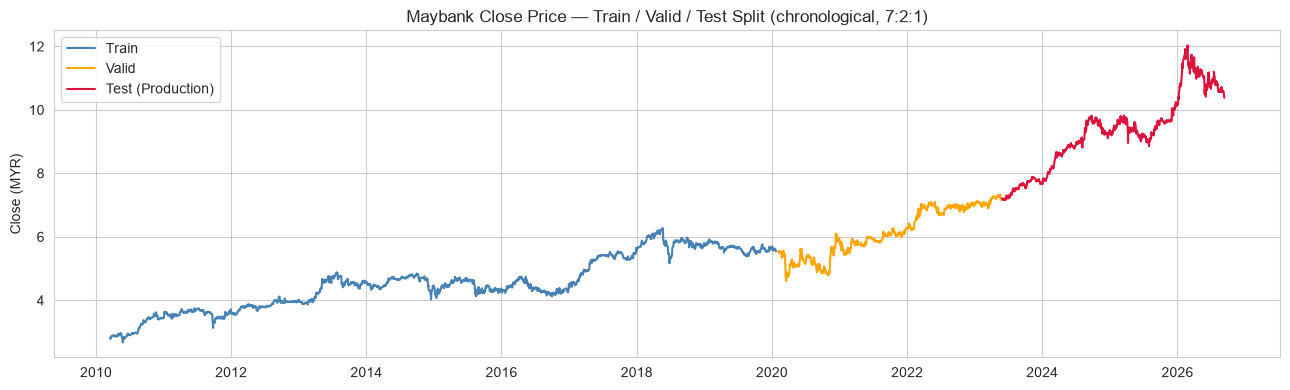

In [85]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(
    train_df.index,
    maybank_clean.loc[train_df.index, "Close"],
    label="Train",
    color="steelblue",
)
ax.plot(
    valid_df.index,
    maybank_clean.loc[valid_df.index, "Close"],
    label="Valid",
    color="orange",
)
ax.plot(
    test_df.index,
    maybank_clean.loc[test_df.index, "Close"],
    label="Test (Production)",
    color="crimson",
)
ax.set_title("Maybank Close Price — Train / Valid / Test Split (chronological, 7:2:1)")
ax.set_ylabel("Close (MYR)")
ax.legend()
plt.tight_layout()
plt.show()

## 4. XGBoost Hyperparameter Tuning

We tune the `XGBClassifier` with a manual/randomized grid search over the validation set, using:
- `early_stopping_rounds` (fit on train, monitored on valid, stops if valid performance doesn't improve)
- `learning_rate`
- `n_estimators` (upper bound — early stopping finds the actual best number of trees per configuration)
- `max_depth`, `subsample`, `colsample_bytree`, `min_child_weight` for regularization / generalization control

We select the configuration with the **highest validation accuracy**, and record the best number of estimators (boosting rounds) discovered via early stopping.

In [86]:
param_grid = {
    "learning_rate":    [0.02, 0.05],
    "max_depth":        [2, 3],
    "subsample":        [0.7, 0.85],
    "colsample_bytree": [0.7, 0.9],
    "min_child_weight": [5, 15, 30],
    "gamma":            [0.1, 0.5],
}

MAX_ESTIMATORS = 500       # ceiling; early stopping finds optimal tree count
EARLY_STOPPING_ROUNDS = 25

keys, values = zip(*param_grid.items())
all_combos = [dict(zip(keys, v)) for v in product(*values)]
print(f"Total hyperparameter combinations to try: {len(all_combos)}")

Total hyperparameter combinations to try: 96


In [87]:
# Suppress verbose Optuna logging output per trial
optuna.logging.set_verbosity(optuna.logging.WARNING)

MAX_ESTIMATORS = 500
EARLY_STOPPING_ROUNDS = 25


def predict_with_confidence(proba_matrix, threshold=0.40):
    """proba_matrix shape: (N, 3) where:

    col 0 = P(STILL), col 1 = P(UP), col 2 = P(DOWN)
    If P(UP) >= threshold and P(UP) > P(DOWN) -> UP (1)
    If P(DOWN) >= threshold and P(DOWN) > P(UP) -> DOWN (2)
    Otherwise -> STILL (0) (sit out in cash)
    """
    preds = np.zeros(len(proba_matrix), dtype=int)
    p_up = proba_matrix[:, 1]
    p_down = proba_matrix[:, 2]

    up_mask = (p_up >= threshold) & (p_up > p_down)
    down_mask = (p_down >= threshold) & (p_down > p_up)

    preds[up_mask] = 1
    preds[down_mask] = 2
    return preds


def objective(trial):
    params = {
        "objective": "multi:softprob",
        "num_class": 3,
        "eval_metric": "mlogloss",
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
        "n_estimators": MAX_ESTIMATORS,
        "early_stopping_rounds": EARLY_STOPPING_ROUNDS,
        # --- Search Space ---
        "learning_rate": trial.suggest_float("learning_rate", 0.015, 0.08),
        "max_depth": trial.suggest_int("max_depth", 2, 4),
        "min_child_weight": trial.suggest_int("min_child_weight", 5, 35),
        "subsample": trial.suggest_float("subsample", 0.65, 0.9),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 0.9),
        "gamma": trial.suggest_float("gamma", 0.05, 0.8),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.05, 3.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.5, 5.0, log=True),
    }

    # Jointly tune confidence threshold to align training objective with inference decision policy
    confidence_threshold = trial.suggest_float("confidence_threshold", 0.35, 0.50)

    model = XGBClassifier(**params)
    model.fit(
        X_train,
        y_train,
        sample_weight=sample_weights_train,
        eval_set=[(X_valid, y_valid)],
        sample_weight_eval_set=[sample_weights_valid],
        verbose=False,
    )

    valid_prob = model.predict_proba(X_valid)
    valid_pred = predict_with_confidence(valid_prob, threshold=confidence_threshold)

    # Optimize for Validation Macro F1 under the exact confidence decision rule used in production
    return f1_score(y_valid, valid_pred, average="macro", zero_division=0)


print("Running Optuna Bayesian Optimization (50 trials)...")
study = optuna.create_study(
    direction="maximize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)
study.optimize(objective, n_trials=50)

best_params = study.best_params
print("\n" + "=" * 60)
print(f"OPTUNA BEST VALID MACRO F1: {study.best_value:.4f}")
print("=" * 60)
for k, v in best_params.items():
    print(
        f"  {k:>22}: {v:.4f}"
        if isinstance(v, float)
        else f"  {k:>22}: {v}"
    )

Running Optuna Bayesian Optimization (50 trials)...

OPTUNA BEST VALID MACRO F1: 0.4142
           learning_rate: 0.0372
               max_depth: 2
        min_child_weight: 16
               subsample: 0.7088
        colsample_bytree: 0.7546
                   gamma: 0.0541
               reg_alpha: 0.5603
              reg_lambda: 1.1021
    confidence_threshold: 0.3802


In [88]:
# Optuna training Results 
trials_df = study.trials_dataframe()

# Extracting params and validation macro F1
param_cols = [c for c in trials_df.columns if c.startswith("params_")]
display_df = trials_df[["number","value"]+ param_cols].copy()
display_df.rename(columns={"number":"trail", "value":"valid_macro_f1"},inplace=True)
display_df.columns = [c.replace("params_","")for c in display_df.columns]

tuning_results_df = (
    display_df.sort_values("valid_macro_f1",ascending =False).reset_index(drop=True)
)

print(f"Top 10 Optuna Trials out of {len(trials_df)} :")
tuning_results_df.head(10)


Top 10 Optuna Trials out of 50 :


,trail,valid_macro_f1,colsample_bytree,confidence_threshold,gamma,learning_rate,max_depth,min_child_weight,reg_alpha,reg_lambda,subsample
0,16,0.414239,0.754624,0.380178,0.054093,0.037213,2,16,0.560347,1.102148,0.708834
1,48,0.412440,0.738700,0.370685,0.201896,0.046751,2,14,0.569439,1.178120,0.694579
2,12,0.405702,0.774920,0.379324,0.208488,0.033826,2,17,0.383446,1.645642,0.697884
3,11,0.403851,0.729424,0.399886,0.430749,0.049036,2,20,0.679820,2.261130,0.683566
4,7,0.403505,0.840659,0.379807,0.105913,0.038189,2,21,2.843179,2.959476,0.685231
5,33,0.403210,0.802056,0.381210,0.147190,0.029052,2,17,2.567097,1.996491,0.661519
6,49,0.401483,0.824620,0.380722,0.050125,0.043126,2,17,0.496097,1.309094,0.677093
7,24,0.400234,0.727811,0.394513,0.203842,0.048675,2,9,0.532903,1.178243,0.733232
8,36,0.400057,0.772203,0.373654,0.151919,0.041456,2,17,0.465921,0.709922,0.731999
9,42,0.399749,0.776226,0.390601,0.126070,0.034086,2,17,1.215686,3.006603,0.663474


### Refit the final model

We refit an `XGBClassifier` using the best hyperparameters, with `n_estimators` fixed to the optimal boosting round count found above (rather than relying on early stopping again), trained on Train and validated against Valid one more time for a clean final artifact.

In [89]:
# --- Refit Final Model with Best Parameters & Find Best Trees ---
# Separate tree parameters from decision-threshold parameter
xgb_best_params = {k: v for k, v in best_params.items() if k != "confidence_threshold"}
CONFIDENCE_THRESHOLD = best_params.get("confidence_threshold", 0.42)

final_model = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    n_estimators=MAX_ESTIMATORS,
    early_stopping_rounds=EARLY_STOPPING_ROUNDS,
    **xgb_best_params,
)

final_model.fit(
    X_train,
    y_train,
    sample_weight=sample_weights_train,
    eval_set=[(X_valid, y_valid)],
    sample_weight_eval_set=[sample_weights_valid],
    verbose=False,
)

best_n_estimators = getattr(final_model, "best_iteration", MAX_ESTIMATORS)
print("Final model refit complete.")
print(f"Optimal boosting rounds (trees): {best_n_estimators}")
print(f"Optimal confidence threshold    : {CONFIDENCE_THRESHOLD:.4f}")

Final model refit complete.
Optimal boosting rounds (trees): 67
Optimal confidence threshold    : 0.3802


## 5. Baseline Comparison

With 3 classes, a naive baseline that always predicts a fixed class (e.g. always "Buy") is a sense check for whether the model is doing any better than blindly exploiting whichever class happens to dominate. We use the **majority class observed in the training data** (typically "Hold", since large single-day moves that clear the threshold band are relatively rare) as the baseline prediction for every row.

In [90]:
majority_class = int(y_train.mode()[0])
majority_class_name = LABEL_NAMES[majority_class]
print(
    f"Majority class in training data: '{majority_class_name}' ({(y_train == majority_class).mean():.2%} of train rows)"
)

baseline_predictions = np.full(len(y_test), majority_class, dtype=int)
baseline_accuracy = accuracy_score(y_test, baseline_predictions)

print(
    f"\nBaseline (always predict '{majority_class_name}') — Test accuracy: {baseline_accuracy:.4f}"
)

# Also report baseline on train/valid for context
print(
    f"Baseline accuracy on Train: {accuracy_score(y_train, np.full(len(y_train), majority_class, dtype=int)):.4f}"
)
print(
    f"Baseline accuracy on Valid: {accuracy_score(y_valid, np.full(len(y_valid), majority_class, dtype=int)):.4f}"
)

Majority class in training data: 'STILL' (54.35% of train rows)

Baseline (always predict 'STILL') — Test accuracy: 0.5709
Baseline accuracy on Train: 0.5435
Baseline accuracy on Valid: 0.4887


## 6. Full Model Performance Results

Comprehensive evaluation across Train, Valid, and Test sets: accuracy, precision, recall, F1, ROC-AUC, confusion matrices, and feature importance.

In [91]:
# --- Confidence Thresholding & Prediction ---
# Uses the optimal threshold discovered during Optuna tuning
print(f"Applying Optuna-Tuned Confidence Threshold: {CONFIDENCE_THRESHOLD:.4f}")

# Probabilities for all splits
train_prob = final_model.predict_proba(X_train)
valid_prob = final_model.predict_proba(X_valid)
test_prob = final_model.predict_proba(X_test)

# Apply confidence thresholding
train_pred = predict_with_confidence(train_prob, threshold=CONFIDENCE_THRESHOLD)
valid_pred = predict_with_confidence(valid_prob, threshold=CONFIDENCE_THRESHOLD)
test_pred = predict_with_confidence(test_prob, threshold=CONFIDENCE_THRESHOLD)


# Evaluate
def evaluate(y_true, pred, prob, split_name):
    return {
        "split": split_name,
        "accuracy": accuracy_score(y_true, pred),
        "precision_macro": precision_score(
            y_true, pred, average="macro", zero_division=0
        ),
        "recall_macro": recall_score(
            y_true, pred, average="macro", zero_division=0
        ),
        "f1_macro": f1_score(y_true, pred, average="macro", zero_division=0),
        "roc_auc_ovr_macro": roc_auc_score(
            y_true, prob, multi_class="ovr", average="macro"
        ),
    }


# Explicitly store test_metrics for subsequent cells
train_metrics = evaluate(y_train, train_pred, train_prob, "Train")
valid_metrics = evaluate(y_valid, valid_pred, valid_prob, "Valid")
test_metrics = evaluate(y_test, test_pred, test_prob, "Test (Production)")

results_summary = pd.DataFrame([train_metrics, valid_metrics, test_metrics]).set_index("split")

print("=== EVALUATION WITH CONFIDENCE THRESHOLDING ===")
results_summary.round(4)

Applying Optuna-Tuned Confidence Threshold: 0.3802
=== EVALUATION WITH CONFIDENCE THRESHOLDING ===


,accuracy,precision_macro,recall_macro,f1_macro,roc_auc_ovr_macro
split,,,,,
Train,0.5597,0.5122,0.4770,0.4871,0.7056
Valid,0.4624,0.4172,0.4137,0.4142,0.5877
Test (Production),0.5149,0.3933,0.3778,0.3756,0.5852


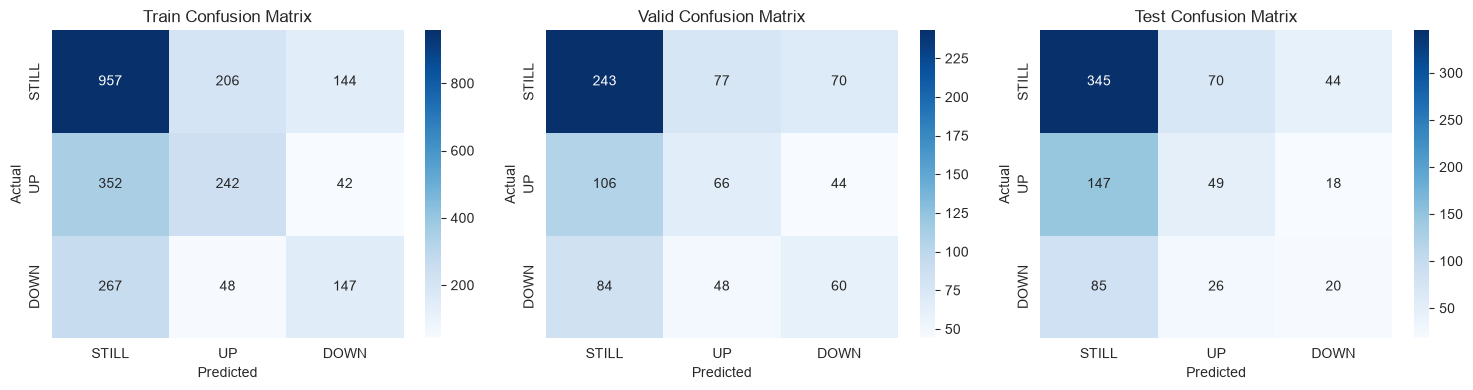

In [92]:
CLASS_LABELS = [0,1,2]
CLASS_NAMES = [LABEL_NAMES[i] for i in CLASS_LABELS]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, y_true, pred) in zip(
    axes,
    [
        ("Train", y_train, train_pred),
        ("Valid", y_valid, valid_pred),
        ("Test", y_test, test_pred),
    ],
):
    cm = confusion_matrix(y_true, pred, labels=CLASS_LABELS)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax,
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES,
    )
    ax.set_title(f"{name} Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

In [93]:
print("=== TRAIN classification report ===")
print(
    classification_report(
        y_train,
        train_pred,
        labels=CLASS_LABELS,
        target_names=CLASS_NAMES,
        zero_division=0,
    )
)

print("=== VALID classification report ===")
print(
    classification_report(
        y_valid,
        valid_pred,
        labels=CLASS_LABELS,
        target_names=CLASS_NAMES,
        zero_division=0,
    )
)

print("=== TEST (Production) classification report ===")
print(
    classification_report(
        y_test,
        test_pred,
        labels=CLASS_LABELS,
        target_names=CLASS_NAMES,
        zero_division=0,
    )
)

=== TRAIN classification report ===
              precision    recall  f1-score   support

       STILL       0.61      0.73      0.66      1307
          UP       0.49      0.38      0.43       636
        DOWN       0.44      0.32      0.37       462

    accuracy                           0.56      2405
   macro avg       0.51      0.48      0.49      2405
weighted avg       0.54      0.56      0.54      2405

=== VALID classification report ===
              precision    recall  f1-score   support

       STILL       0.56      0.62      0.59       390
          UP       0.35      0.31      0.32       216
        DOWN       0.34      0.31      0.33       192

    accuracy                           0.46       798
   macro avg       0.42      0.41      0.41       798
weighted avg       0.45      0.46      0.46       798

=== TEST (Production) classification report ===
              precision    recall  f1-score   support

       STILL       0.60      0.75      0.67       459
         

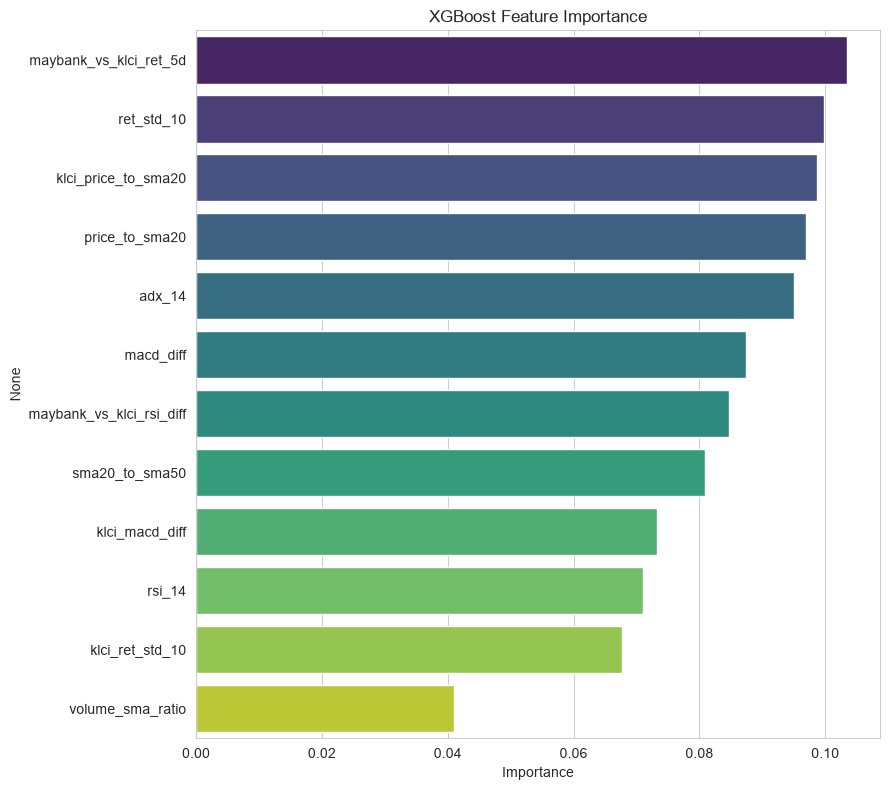


Share of total importance coming from FBM KLCI / relative-to-market features: 42.78%


In [94]:
# Feature importance — which signals (Maybank technicals vs KLCI market-context) matter most
importance = pd.Series(
    final_model.feature_importances_, index=feature_cols
).sort_values(ascending=False)

plt.figure(figsize=(9, 8))
sns.barplot(x=importance.values, y=importance.index, palette="viridis")
plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

klci_importance_share = importance[
    [c for c in importance.index if c.startswith("klci_") or "vs_klci" in c]
].sum()
print(
    f"\nShare of total importance coming from FBM KLCI / relative-to-market features: {klci_importance_share / importance.sum():.2%}"
)

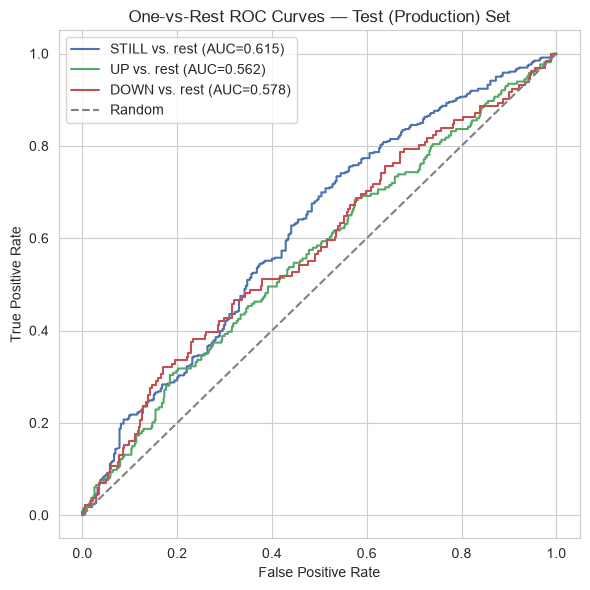

In [95]:
# One-vs-Rest ROC curves (one per class) on the Test (production) set — with 3 classes there is
# no single ROC curve, so we plot each class against "everything else" and report its own AUC.
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test, classes=CLASS_LABELS)
colors = ["#4C72B0", "#55A868", "#C44E52"]

plt.figure(figsize=(6, 6))
for i, cls in enumerate(CLASS_LABELS):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], test_prob[:, i])
    auc = roc_auc_score(y_test_bin[:, i], test_prob[:, i])
    plt.plot(
        fpr, tpr, label=f"{LABEL_NAMES[cls]} vs. rest (AUC={auc:.3f})", color=colors[i]
    )

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("One-vs-Rest ROC Curves — Test (Production) Set")
plt.legend()
plt.tight_layout()
plt.show()

## 7. Test (Production) Score

The Test split (final 10% chronologically) was **never touched during tuning** — this is our best estimate of how the model would perform if deployed "live" going forward. We compare it directly against the majority-class baseline on the *same* Test set.

In [96]:

# --- Production Test Performance Summary ---
print("=" * 55)
print("PRODUCTION (TEST) PERFORMANCE SUMMARY")
print("=" * 55)
print(f"Test period             : {test_df.index.min().date()} -> {test_df.index.max().date()}")
print(f"Number of test days     : {len(y_test)}")
print("-" * 55)
print(f"XGBoost Model Accuracy  : {test_metrics['accuracy']:.4f}")
print(f"Baseline Accuracy       : {baseline_accuracy:.4f}  (always predicts '{majority_class_name}')")
print(f"Improvement over base.  : {test_metrics['accuracy'] - baseline_accuracy:+.4f}")
print("-" * 55)
print(f"Precision (macro)       : {test_metrics['precision_macro']:.4f}")
print(f"Recall (macro)          : {test_metrics['recall_macro']:.4f}")
print(f"F1-score (macro)        : {test_metrics['f1_macro']:.4f}")
print(f"ROC-AUC (OvR macro)     : {test_metrics['roc_auc_ovr_macro']:.4f}")
print("=" * 55)

comparison_df = pd.DataFrame(
    {
        "Model": ["XGBoost (tuned)", f"Baseline (always {majority_class_name})"],
        "Accuracy": [test_metrics["accuracy"], baseline_accuracy],
    }
)
comparison_df

PRODUCTION (TEST) PERFORMANCE SUMMARY
Test period             : 2023-05-31 -> 2026-09-11
Number of test days     : 804
-------------------------------------------------------
XGBoost Model Accuracy  : 0.5149
Baseline Accuracy       : 0.5709  (always predicts 'STILL')
Improvement over base.  : -0.0560
-------------------------------------------------------
Precision (macro)       : 0.3933
Recall (macro)          : 0.3778
F1-score (macro)        : 0.3756
ROC-AUC (OvR macro)     : 0.5852


,Model,Accuracy
0,XGBoost (tuned),0.514925
1,Baseline (always STILL),0.570896


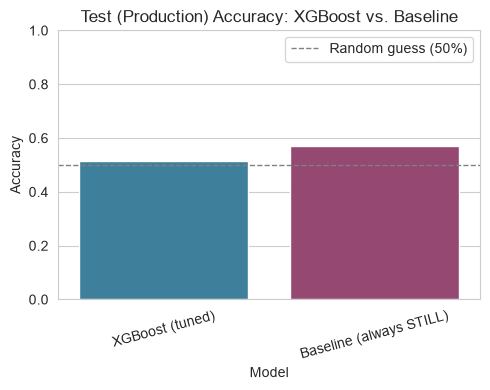

In [97]:
plt.figure(figsize=(5, 4))
sns.barplot(data=comparison_df, x="Model", y="Accuracy", palette=["#2E86AB", "#A23B72"])
plt.ylim(0, 1)
plt.axhline(0.5, linestyle="--", color="gray", linewidth=1, label="Random guess (50%)")
plt.xticks(rotation=15)
plt.title("Test (Production) Accuracy: XGBoost vs. Baseline")
plt.legend()
plt.tight_layout()
plt.show()

## 8. Mock Trading Simulation (on Test / Production Data)

With a 3-way **Buy / Hold / Sell** signal trained on a calibrated **5-day forward swing horizon**, the simulation models realistic swing trading behavior:

- **Holding Horizon Alignment:** When an **UP (1)** or **DOWN (2)** signal triggers, the position is entered and held for **5 trading days**.
- **STILL (0)** indicates neutrality / lack of conviction; it does not exit an active trade prematurely. Ongoing positions continue until their 5-day holding period expires (or unless flipped by an opposing signal).
- **Buy (1)** → go **long** (+1)
- **Sell (2)** → go **short** (-1) *(or exit to cash in long-only mode)*
- **Cash (0)** → 0% return when holding period expires without new signals.

We compare three portfolios on the Test set:
- **XGBoost Model strategy** — acts on the tuned model's predictions with 5-day holding persistence.
- **Baseline strategy** — acts on the majority-class baseline's predictions.
- **Buy & Hold** — stays 100% invested in Maybank for the entire test period, paying one broker entry fee.

All strategies incur `BROKER_FEE = 0.10%` per transaction side whenever position changes.

In [98]:
# --- Swing Simulation with Broker Fees, Holding Horizon & Confidence Thresholding ---
BROKER_FEE = 0.001  # 0.10% per trade side
STARTING_CAPITAL = 10_000

# Daily 1-day forward actual return to mark-to-market positions daily: (Close[t+1] - Close[t]) / Close[t]
daily_actual_return = (
    maybank_clean["Close"].pct_change().shift(-1).loc[test_df.index]
)


def signals_to_holding_positions(signals, horizon=HORIZON):
    """Translates discrete trading signals into daily positions with a multi-day holding period.

    When an UP (1) or DOWN (2) signal fires, the position is entered and held for `horizon` days.
    A STILL (0) signal does not exit an active trade prematurely; the position is maintained
    until the `horizon` days expire. An opposing signal flips the position immediately.
    """
    n = len(signals)
    positions = np.zeros(n, dtype=int)
    current_pos = 0
    days_remaining = 0

    for i in range(n):
        sig = signals.iloc[i] if hasattr(signals, "iloc") else signals[i]
        if sig == 1:
            current_pos = 1
            days_remaining = horizon
        elif sig == 2:
            current_pos = -1
            days_remaining = horizon
        elif days_remaining > 0:
            days_remaining -= 1
            if days_remaining == 0:
                current_pos = 0
        else:
            current_pos = 0

        positions[i] = current_pos

    return pd.Series(positions, index=test_df.index)


sim = pd.DataFrame(
    {
        "actual_return": daily_actual_return,
        "model_raw_signal": test_pred,
        "baseline_raw_signal": baseline_predictions,
    },
    index=test_df.index,
)

# Convert discrete signals into persistent multi-day holding positions matching HORIZON
sim["model_position"] = signals_to_holding_positions(
    sim["model_raw_signal"], horizon=HORIZON
)
sim["baseline_position"] = signals_to_holding_positions(
    sim["baseline_raw_signal"], horizon=HORIZON
)


def compute_net_strategy_returns(position, actual_returns, fee_rate):
    gross_return = position * actual_returns

    # Fee charged only when position changes (entry, exit, or flip)
    prev_position = position.shift(1).fillna(0)
    turnover = (position - prev_position).abs()
    tx_cost = turnover * fee_rate
    net_return = gross_return - tx_cost
    return gross_return, tx_cost, net_return, turnover


(
    sim["model_gross_return"],
    sim["model_fee_cost"],
    sim["model_strategy_return"],
    model_turnover,
) = compute_net_strategy_returns(
    sim["model_position"], sim["actual_return"], BROKER_FEE
)

(
    sim["baseline_gross_return"],
    sim["baseline_fee_cost"],
    sim["baseline_strategy_return"],
    _,
) = compute_net_strategy_returns(
    sim["baseline_position"], sim["actual_return"], BROKER_FEE
)

# Buy & Hold (stays 100% invested throughout the test period, paying 1 entry fee)
sim["UP_STILL_return"] = sim["actual_return"].copy()
sim.loc[sim.index[0], "UP_STILL_return"] -= BROKER_FEE

sim["model_equity"] = STARTING_CAPITAL * (1 + sim["model_strategy_return"]).cumprod()
sim["baseline_equity"] = (
    STARTING_CAPITAL * (1 + sim["baseline_strategy_return"]).cumprod()
)
sim["UP_STILL_equity"] = STARTING_CAPITAL * (1 + sim["UP_STILL_return"]).cumprod()

sim["model_signal_label"] = sim["model_raw_signal"].map(LABEL_NAMES)

total_trades = int(model_turnover.sum())
print("=== HIGH-CONVICTION SWING SIMULATION (HORIZON-ALIGNED) ===")
print(f"Holding Horizon      : {HORIZON} trading days")
print(f"Confidence Threshold : {CONFIDENCE_THRESHOLD:.1%}")
print(f"Total trade turnover : {total_trades} transactions")
print(
    f"Total fees paid      : MYR {sim['model_fee_cost'].sum() * STARTING_CAPITAL:.2f}"
)
print("\nRaw Signal Distribution:")
print(sim["model_signal_label"].value_counts())
print("\nPosition Distribution (Days in Market):")
pos_counts = sim["model_position"].map({1: "LONG", -1: "SHORT", 0: "CASH"}).value_counts()
print(pos_counts)
sim.tail()

=== HIGH-CONVICTION SWING SIMULATION (HORIZON-ALIGNED) ===
Holding Horizon      : 5 trading days
Confidence Threshold : 38.0%
Total trade turnover : 93 transactions
Total fees paid      : MYR 930.00

Raw Signal Distribution:
model_signal_label
STILL    577
UP       145
DOWN      82
Name: count, dtype: int64

Position Distribution (Days in Market):
model_position
CASH     402
LONG     243
SHORT    159
Name: count, dtype: int64


,actual_return,model_raw_signal,baseline_raw_signal,model_position,baseline_position,model_gross_return,model_fee_cost,model_strategy_return,baseline_gross_return,baseline_fee_cost,baseline_strategy_return,UP_STILL_return,model_equity,baseline_equity,UP_STILL_equity,model_signal_label
Date,,,,,,,,,,,,,,,,
2026-09-07,-0.003781,0,0,0,0,-0.000000,0.001,-0.001000,-0.0,0.0,-0.0,-0.003781,14385.267007,10000.0,14586.702227,STILL
2026-09-08,-0.007590,0,0,0,0,-0.000000,0.000,-0.000000,-0.0,0.0,-0.0,-0.007590,14385.267007,10000.0,14475.987325,STILL
2026-09-09,0.000000,1,0,1,0,0.000000,0.001,-0.001000,0.0,0.0,0.0,0.000000,14370.881740,10000.0,14475.987325,UP
2026-09-10,-0.007648,0,0,1,0,-0.007648,0.000,-0.007648,-0.0,0.0,-0.0,-0.007648,14260.970704,10000.0,14365.272423,STILL
2026-09-11,0.007707,1,0,1,0,0.007707,0.000,0.007707,0.0,0.0,0.0,0.007707,14370.881740,10000.0,14475.987325,UP


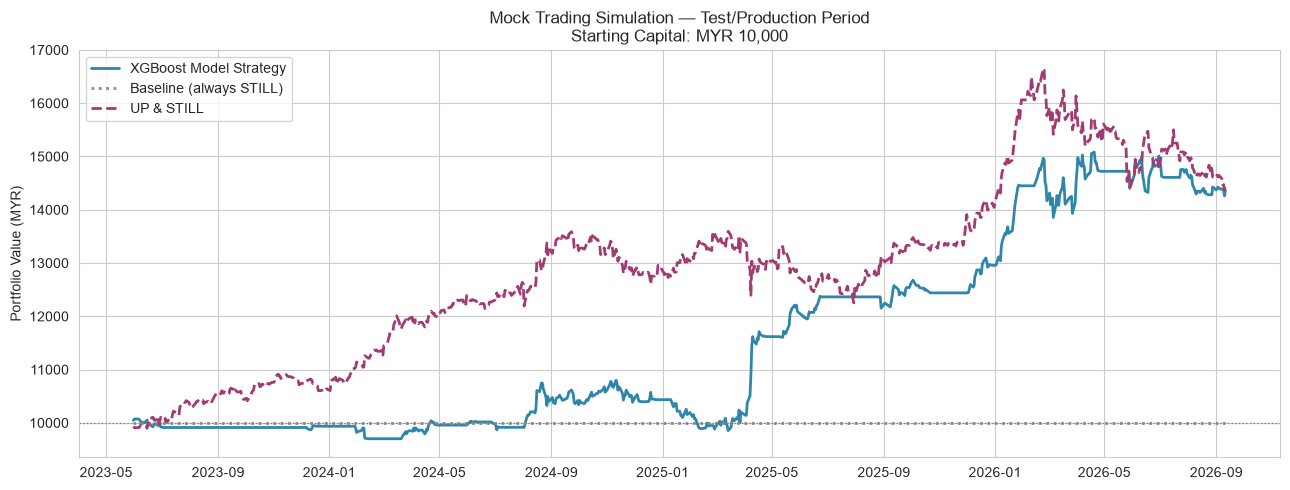

In [99]:
plt.figure(figsize=(13, 5))
plt.plot(
    sim.index,
    sim["model_equity"],
    label="XGBoost Model Strategy",
    color="#2E86AB",
    linewidth=2,
)
plt.plot(
    sim.index,
    sim["baseline_equity"],
    label=f"Baseline (always {majority_class_name})",
    color="#8C8C8C",
    linewidth=2,
    linestyle=":",
)
plt.plot(
    sim.index,
    sim["UP_STILL_equity"],
    label="UP & STILL",
    color="#A23B72",
    linewidth=2,
    linestyle="--",
)
plt.axhline(STARTING_CAPITAL, color="gray", linewidth=1, linestyle=":")
plt.title(
    f"Mock Trading Simulation — Test/Production Period\nStarting Capital: MYR {STARTING_CAPITAL:,}"
)
plt.ylabel("Portfolio Value (MYR)")
plt.legend()
plt.tight_layout()
plt.show()

In [100]:
def sim_summary(returns, equity, name):
    total_return = equity.iloc[-1] / STARTING_CAPITAL - 1
    n_days = len(returns)
    ann_factor = 252 / n_days
    cagr = (1 + total_return) ** ann_factor - 1
    vol = returns.std() * np.sqrt(252)
    sharpe = (returns.mean() * 252) / (returns.std() * np.sqrt(252) + 1e-9)
    max_dd = (equity / equity.cummax() - 1).min()
    win_rate = (returns > 0).mean()

    return {
        "Strategy": name,
        "Final Equity (MYR)": round(equity.iloc[-1], 2),
        "Total Return": f"{total_return:.2%}",
        "Annualized Return (CAGR)": f"{cagr:.2%}",
        "Annualized Volatility": f"{vol:.2%}",
        "Sharpe Ratio (rf=0)": round(sharpe, 3),
        "Max Drawdown": f"{max_dd:.2%}",
        "Win Rate (days)": f"{win_rate:.2%}",
    }


sim_results = pd.DataFrame(
    [
        sim_summary(sim["model_strategy_return"], sim["model_equity"], "XGBoost Model"),
        sim_summary(
            sim["baseline_strategy_return"],
            sim["baseline_equity"],
            f"Baseline (always {majority_class_name})",
        ),
        sim_summary(sim["UP_STILL_return"], sim["UP_STILL_equity"], "UP & STILL"),
    ]
).set_index("Strategy")

sim_results

,Final Equity (MYR),Total Return,Annualized Return (CAGR),Annualized Volatility,Sharpe Ratio (rf=0),Max Drawdown,Win Rate (days)
Strategy,,,,,,,
XGBoost Model,14370.88,43.71%,12.04%,10.03%,1.183,-8.75%,24.63%
Baseline (always STILL),10000.00,0.00%,0.00%,0.00%,0.000,0.00%,0.00%
UP & STILL,14475.99,44.76%,12.29%,12.68%,0.978,-13.74%,44.90%


### Interpretation

- If the **XGBoost Model** strategy shows a higher Sharpe ratio / lower drawdown than Buy & Hold and the baseline, that suggests the model's Buy/Hold/Sell signal (partly informed by FBM KLCI market-context features) has some practical trading value beyond raw accuracy.
- Because "Hold" sits out entirely (0% return, 0% risk) and "Sell" actively bets against the stock, this 3-class strategy can behave very differently from a simple always-invested benchmark — check the **signal distribution** printed above to see how often the model actually chose to act versus stay in cash.
- Remember that **accuracy alone doesn't capture magnitude of moves** — a model can be right more often on small moves and wrong on big ones (or vice versa), and this simulation doesn't weight position size by model confidence.
- Always treat this as a **sanity check**, not investment advice — no transaction costs, slippage, dividends, margin/borrowing costs for shorting, or realistic position sizing were modeled, and past performance on this single stock/period is not a guarantee of future results.